# Mini Project 2
**Name:** Talha  

This project analyzes the differences between **standpunkt grades**  
and **written exam grades** in Norwegian high schools.

## Setup

The required libraries (pandas and matplotlib) are used for data analysis  
and visualization.

In [1]:
try:
    import pandas
except ImportError:
    install("pandas")

try:
    import matplotlib
except ImportError:
    install("matplotlib")

import pandas as pd
import matplotlib.pyplot as plt
import os

## Create Graphs Folder

A folder named **graphs** is created to store all generated visualizations.  
This improves project organization and keeps outputs structured.

In [2]:
if not os.path.exists("graphs"):
    os.makedirs("graphs")

## Load Data

The datasets are loaded from CSV files.

- The files use **semicolon (;) as separator**
- Encoding is set to **latin1** to handle special characters

In [3]:
df_stand = pd.read_csv("standpunkt_grades_vgs.csv", sep=";", encoding="latin1")
df_exam = pd.read_csv("skriftlig_grades_vgs.csv", sep=";", encoding="latin1")

## Clean Column Names

Column names are cleaned by removing unnecessary spaces  
to ensure consistency and avoid errors during processing.

In [4]:
df_stand.columns = df_stand.columns.str.strip()
df_exam.columns = df_exam.columns.str.strip()

## Rename Columns

Long column names are simplified:

- Standpunkt grades → `standpunkt`
- Exam grades → `exam`

This makes the dataset easier to work with.

In [5]:
df_stand = df_stand.rename(columns={
    "2024-25.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter": "standpunkt"
})

df_exam = df_exam.rename(columns={
    "2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter": "exam"
})

## Select Required Columns

Only the necessary columns are selected:

- Fylke (region)
- Vurderingsfagnavn (subject)
- Grades

This simplifies the dataset and improves performance.

---

In [6]:
df_stand = df_stand[["Fylke", "Vurderingsfagnavn", "standpunkt"]]
df_exam = df_exam[["Fylke", "Vurderingsfagnavn", "exam"]]

## Convert Grades to Numeric

Grades are converted to numeric values:

- "4,5" → 4.5  
- Invalid values (like "*") are handled safely  

Missing values are removed to ensure accurate analysis.

---

In [7]:
df_stand["standpunkt"] = pd.to_numeric(
    df_stand["standpunkt"].astype(str).str.replace(",", "."),
    errors="coerce"
)

df_exam["exam"] = pd.to_numeric(
    df_exam["exam"].astype(str).str.replace(",", "."),
    errors="coerce"
)

# Remove missing values
df_stand = df_stand.dropna()
df_exam = df_exam.dropna()

## Merge Data

The two datasets are merged based on:

- Fylke  
- Vurderingsfagnavn  

This allows comparison between standpunkt and exam grades.

In [8]:
df = pd.merge(df_stand, df_exam,
              on=["Fylke", "Vurderingsfagnavn"])

## Calculate Difference

The difference between grades is calculated:

Difference = Standpunkt - Exam

- Positive → standpunkt higher  
- Negative → exam higher  

In [9]:
df["difference"] = df["standpunkt"] - df["exam"]


## Basic Analysis

The **average difference** is calculated to understand  
the general trend across all data.

In [10]:
avg_diff = df["difference"].mean()
print("Average Difference:", avg_diff)

Average Difference: 0.47531039375665124


## Group Analysis by Subject

The average difference is analyzed for each subject separately.

This helps identify how grading differences vary across subjects.

In [11]:
subject_diff = df.groupby("Vurderingsfagnavn")["difference"].mean()

print("\nAverage Difference by Subject:")
print(subject_diff)



Average Difference by Subject:
Vurderingsfagnavn
Engelsk vg1 studieforberedende utdanningsprogram                                                                   0.343909
Engelsk vg1 yrkesfaglige utdanningsprogram                                                                         0.531164
Fransk I                                                                                                           0.888571
Fransk I+II                                                                                                        0.428571
Fransk II                                                                                                          0.562385
Italiensk I                                                                                                        0.050000
Italiensk I+II                                                                                                     0.500000
Japansk I                                                                         

## Visualization (Bar Chart)

A horizontal bar chart is created to:

- Compare subjects  
- Visualize differences clearly  

Long subject names are shortened for readability.

The figure is saved as:

**difference_between_standpunkt_and_exam.png**

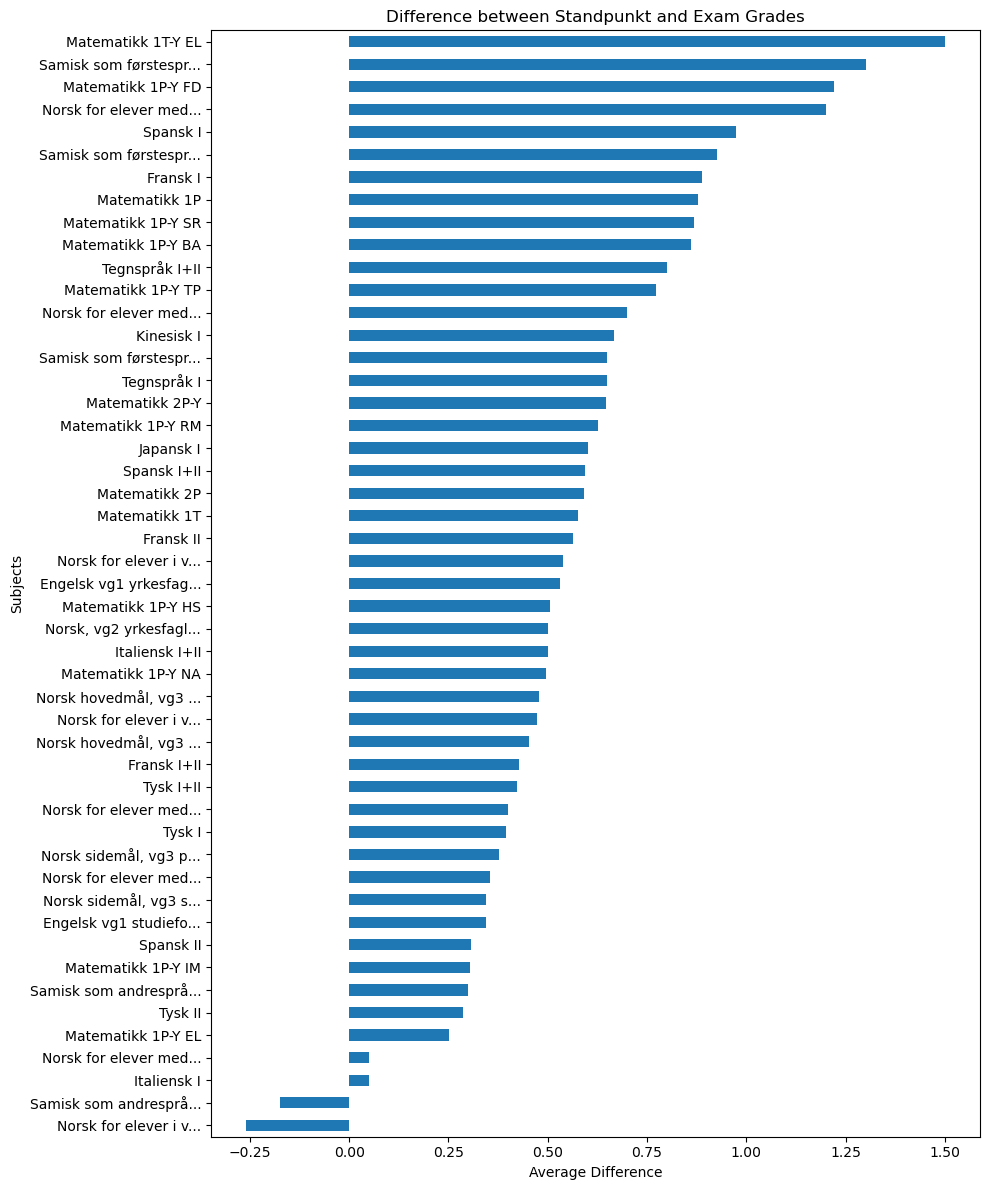

In [12]:
def shorten_label(label):
    label = str(label)
    return label[:20] + "..." if len(label) > 20 else label

plot_data = subject_diff.copy()
plot_data.index = [shorten_label(label) for label in plot_data.index]

plt.figure(figsize=(10, 12))
plot_data.sort_values().plot(kind="barh")

plt.title("Difference between Standpunkt and Exam Grades")
plt.xlabel("Average Difference")
plt.ylabel("Subjects")

plt.tight_layout()

# Save figure
plt.savefig("graphs/difference_between_standpunkt_and_exam.png")

plt.show()


## Histogram

A histogram is created to show:

- Distribution of differences  
- Frequency of values  

The figure is saved as:

**distribution_of_grade_differences.png**

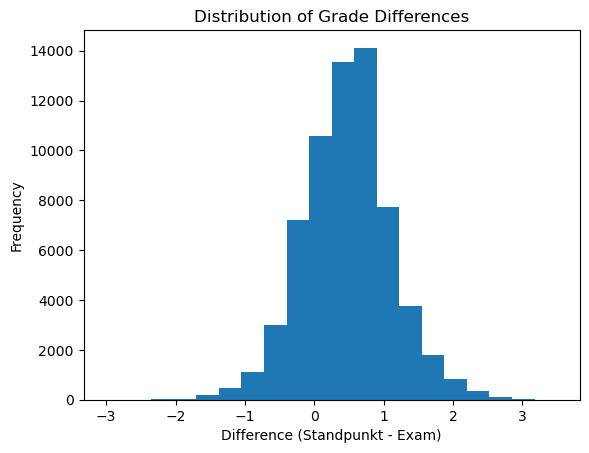

In [13]:
plt.figure()
df["difference"].plot(kind="hist", bins=20)

plt.title("Distribution of Grade Differences")
plt.xlabel("Difference (Standpunkt - Exam)")
plt.ylabel("Frequency")

# Save figure
plt.savefig("graphs/distribution_of_grade_differences.png")

plt.show()


## Final Conclusion

If the average difference is positive:

Standpunkt grades are generally higher than exam grades.

Otherwise:

Exam grades are higher.

In [14]:

print("\nAverage difference: ",avg_diff)
if avg_diff > 0:
    print("\nConclusion: Standpunkt grades are generally higher than exam grades.")
else:
    print("\nConclusion: Exam grades are higher than standpunkt grades.")

print("\nProject completed successfully.")




Average difference:  0.47531039375665124

Conclusion: Standpunkt grades are generally higher than exam grades.

Project completed successfully.


## Interpretation

The average difference is approximately **0.47**, indicating that  
standpunkt grades are generally higher than written exam grades.

In the figure *"difference_between_standpunkt_and_exam.png"*,  
most subjects show positive differences, meaning teacher-based  
assessment tends to give higher grades.

Some subjects show small or negative differences,  
indicating that exam grades can sometimes be similar or higher.

The variation across subjects suggests that grading differences  
depend on subject type and assessment method.

In the figure *"distribution_of_grade_differences.png"*,  
the histogram shows a roughly normal distribution centered above zero,  
confirming that most differences are positive.

This supports the conclusion that standpunkt grades are generally higher.